# 06 · Analysis — Quick Test & Validation
**Script chính:** `scripts/run_analysis.py` + `scripts/run_backtest.py`
**Notebook này:** Load tất cả outputs → kiểm tra sensitivity, alpha, figures, feature importance. Verify logic khớp script.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import load_config, SECTOR_MAP
from src.backtest import compute_metrics
from src.utils.io import load

cfg = load_config(ROOT / 'configs' / 'base.yaml')

## 1. Load All Equity Curves & Metrics

In [2]:
out = cfg.dir_outputs
equities = {}
for name, fname in [('ML_Full_EW', 'equity_full.parquet'),
                     ('ML_Full_CW', 'equity_cw.parquet'),
                     ('BH_QQQ', 'equity_benchmark_qqq.parquet'),
                     ('BH_MCap10', 'equity_benchmark_mcap10.parquet'),
                     ('BH_Full', 'equity_benchmark_full.parquet')]:
    path = out / fname
    if path.exists():
        equities[name] = load(path)

all_metrics = {n: compute_metrics(eq) for n, eq in equities.items()}
metrics_df = pd.DataFrame(all_metrics).T
cols = ['CAGR', 'Sharpe', 'Max_Drawdown', 'Calmar', 'Sortino', 'Win_Rate']
print(metrics_df[[c for c in cols if c in metrics_df.columns]].round(3).to_string())
print(f"\nLoaded {len(equities)} equity curves")

             CAGR  Sharpe  Max_Drawdown  Calmar  Sortino  Win_Rate
ML_Full_EW  0.309   0.854        -0.372   0.832    1.196     0.533
ML_Full_CW  0.333   0.893        -0.376   0.885    1.240     0.537
BH_QQQ      0.186   0.671        -0.351   0.530    0.872     0.562
BH_MCap10   0.341   0.895        -0.575   0.592    1.258     0.549
BH_Full     0.203   0.726        -0.324   0.624    0.955     0.562

Loaded 5 equity curves


## 1b. Data Inspection — nhìn thẳng vào metrics + equity

Print full `metrics_df` (tất cả columns), full sensitivity tables, full alpha_stats, holdings/exposure raw từ trade_log để xác nhận từng số khớp với report.

In [3]:
print("--- metrics_df FULL (all columns) ---")
print(metrics_df.round(4).to_string())

print(f"\n--- All metrics_df columns ({len(metrics_df.columns)}): ---")
print(metrics_df.columns.tolist())

print("\n--- Sample equity curve: ML_Full_CW head + tail ---")
eq = equities['ML_Full_CW']
print(eq.head(5).round(6).to_string())
print("...")
print(eq.tail(5).round(6).to_string())

print("\n--- backtest_metrics.csv RAW ---")
script_metrics_path = cfg.dir_outputs / 'metrics' / 'backtest_metrics.csv'
if script_metrics_path.exists():
    print(pd.read_csv(script_metrics_path, index_col=0).round(4).to_string())

print("\n--- alpha_stats.csv RAW ---")
alpha_path = cfg.dir_outputs / 'metrics' / 'alpha_stats.csv'
if alpha_path.exists():
    print(pd.read_csv(alpha_path).round(4).to_string(index=False))

print("\n--- All output files in metrics/ ---")
met_dir = cfg.dir_outputs / 'metrics'
for f in sorted(met_dir.glob('*.csv')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} {size_kb:>8.1f} KB")
for f in sorted(met_dir.glob('*.parquet')):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:40s} {size_kb:>8.1f} KB")

--- metrics_df FULL (all columns) ---
            Total_Return    CAGR  Sharpe  Sortino  Max_Drawdown  Calmar  VaR_95  Win_Rate  MDD_Duration  Tail_Ratio  Avg_Daily_Ret  Std_Daily_Ret  N_Days
ML_Full_EW        4.1922  0.3092  0.8543   1.1957       -0.3717  0.8319 -0.0327    0.5326         291.0      1.0721         0.0013         0.0212  1536.0
ML_Full_CW        4.7984  0.3331  0.8931   1.2395       -0.3763  0.8851 -0.0325    0.5371         291.0      1.0752         0.0014         0.0218  1536.0
BH_QQQ            1.8405  0.1862  0.6712   0.8722       -0.3512  0.5302 -0.0256    0.5617         473.0      0.9090         0.0008         0.0161  1476.0
BH_MCap10         5.0069  0.3408  0.8953   1.2583       -0.5753  0.5923 -0.0403    0.5488         537.0      0.9455         0.0015         0.0238  1476.0
BH_Full           2.0883  0.2025  0.7265   0.9554       -0.3244  0.6245 -0.0246    0.5623         489.0      0.9677         0.0009         0.0162  1476.0

--- All metrics_df columns (13): ---


## 2. Equity Curves & Drawdown

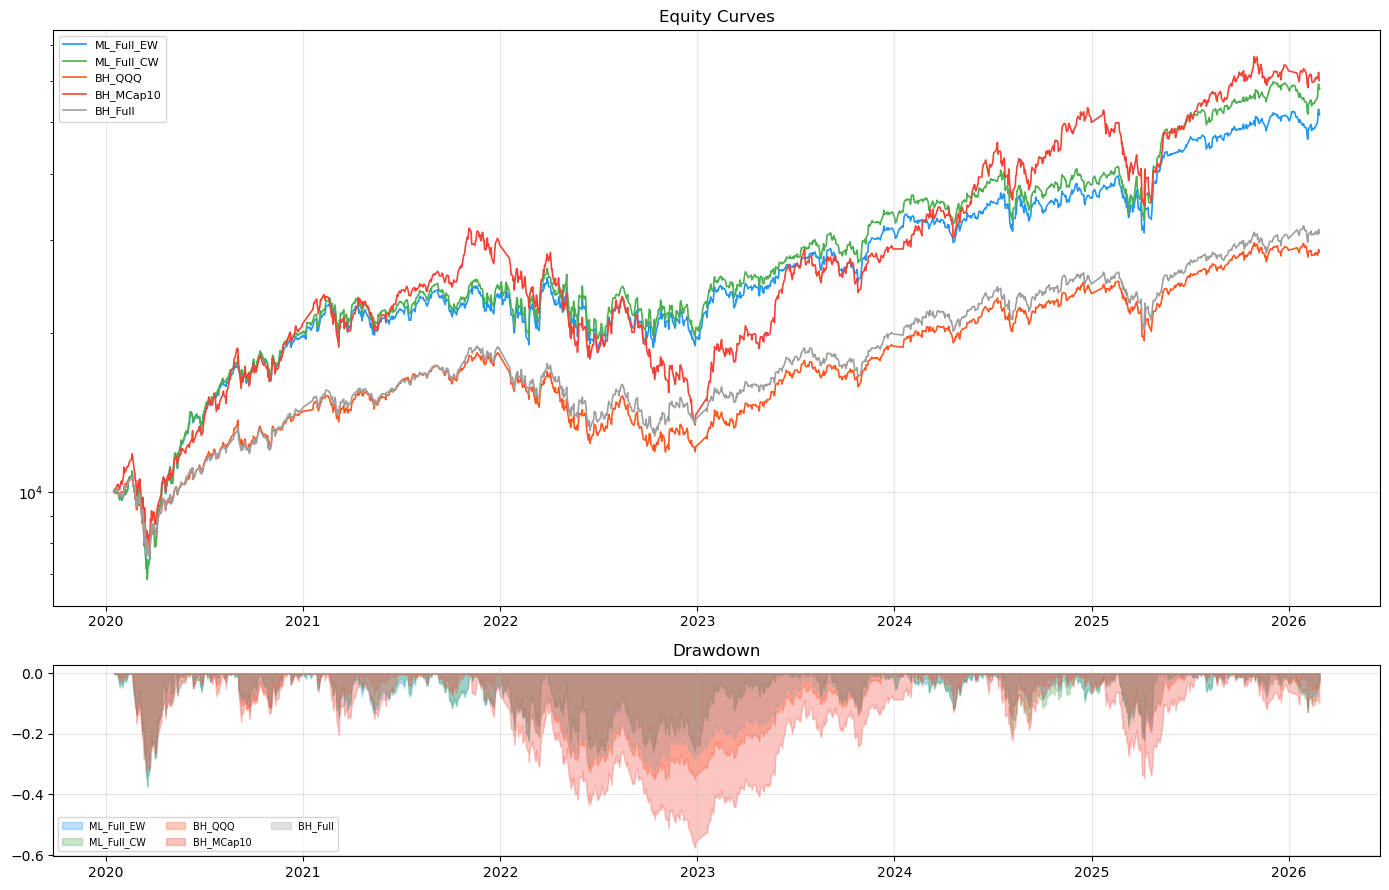

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})
colors = {'ML_Full_EW': '#2196F3', 'ML_Full_CW': '#4CAF50',
          'BH_QQQ': '#FF5722', 'BH_MCap10': '#F44336', 'BH_Full': '#9E9E9E'}
for name, eq in equities.items():
    axes[0].plot(eq.index, eq['equity'], label=name, linewidth=1.2, color=colors.get(name))
axes[0].set_title('Equity Curves'); axes[0].set_yscale('log'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
for name, eq in equities.items():
    dd = eq['equity'] / eq['equity'].cummax() - 1
    axes[1].fill_between(dd.index, dd, 0, alpha=0.3, label=name, color=colors.get(name))
axes[1].set_title('Drawdown'); axes[1].legend(fontsize=7, ncol=3); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3. Annual Returns Comparison

      ML_Full_EW  ML_Full_CW  BH_QQQ  BH_MCap10  BH_Full
date                                                    
2020       0.979       1.013   0.419      1.083    0.444
2021       0.176       0.199   0.274      0.407    0.286
2022      -0.156      -0.151  -0.326     -0.521   -0.259
2023       0.601       0.647   0.549      1.053    0.446
2024       0.143       0.130   0.256      0.736    0.242
2025       0.411       0.520   0.208      0.252    0.219
2026       0.023       0.001  -0.008     -0.041    0.025


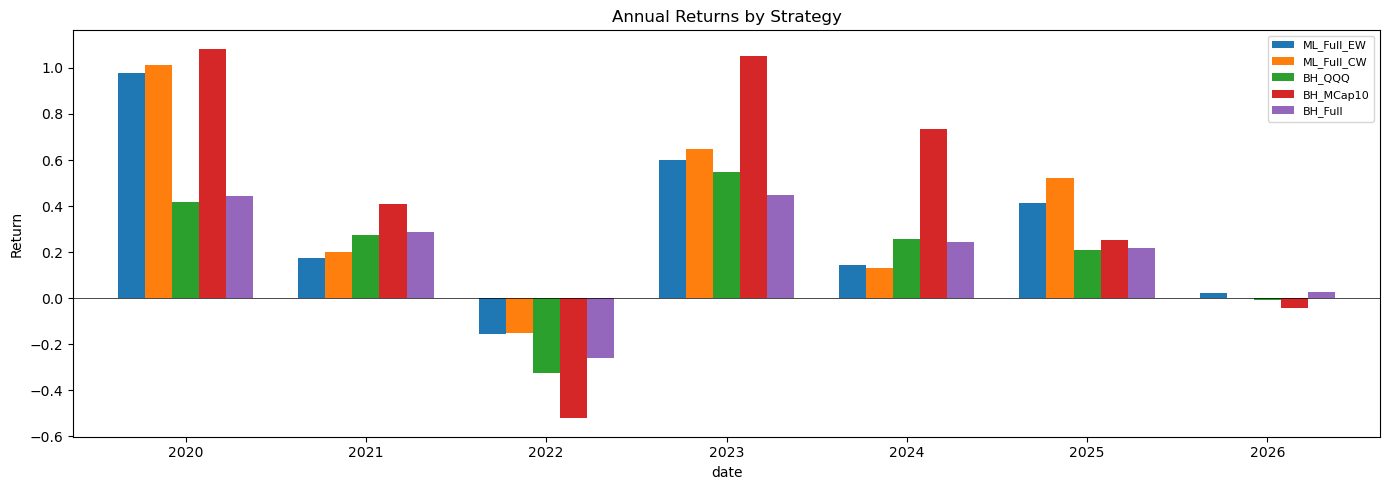

In [5]:
annual = {}
for name, eq in equities.items():
    rets = eq['daily_ret'].copy()
    rets.index = pd.to_datetime(rets.index)
    yearly = (1 + rets).groupby(rets.index.year).prod() - 1
    annual[name] = yearly
ann_df = pd.DataFrame(annual)
print(ann_df.round(3).to_string())

fig, ax = plt.subplots(figsize=(14, 5))
ann_df.plot(kind='bar', ax=ax, width=0.75)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_title('Annual Returns by Strategy'); ax.set_ylabel('Return'); ax.legend(fontsize=8)
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

## 3b. Portfolio value journey (start = $10,000)

How much would $10,000 invested at the start of the OOS period be worth at the end of each year? Translates compounded returns into dollar terms — much more intuitive than CAGR for stakeholders.

Portfolio value by year-end (start $10,000):

         ML_Full_EW    ML_Full_CW        BH_QQQ     BH_MCap10       BH_Full
Start  $     10,000  $     10,000  $     10,000  $     10,000  $     10,000
2020   $     19,790  $     20,134  $     14,195  $     20,829  $     14,439
2021   $     23,273  $     24,139  $     18,087  $     29,312  $     18,572
2022   $     19,646  $     20,487  $     12,195  $     14,031  $     13,763
2023   $     31,453  $     33,733  $     18,885  $     28,811  $     19,906
2024   $     35,948  $     38,104  $     23,715  $     50,024  $     24,731
2025   $     50,738  $     57,919  $     28,641  $     62,627  $     30,135
2026   $     51,922  $     57,984  $     28,405  $     60,069  $     30,883

--- Final summary ---
Period: 6.11 years

  ML_Full_EW     final=$     51,922  (5.19x)  total= +419.2%
  ML_Full_CW     final=$     57,984  (5.80x)  total= +479.8%
  BH_QQQ         final=$     28,405  (2.84x)  total= +184.0%
  BH_MCap10      final=$     60,069  (6.01x)

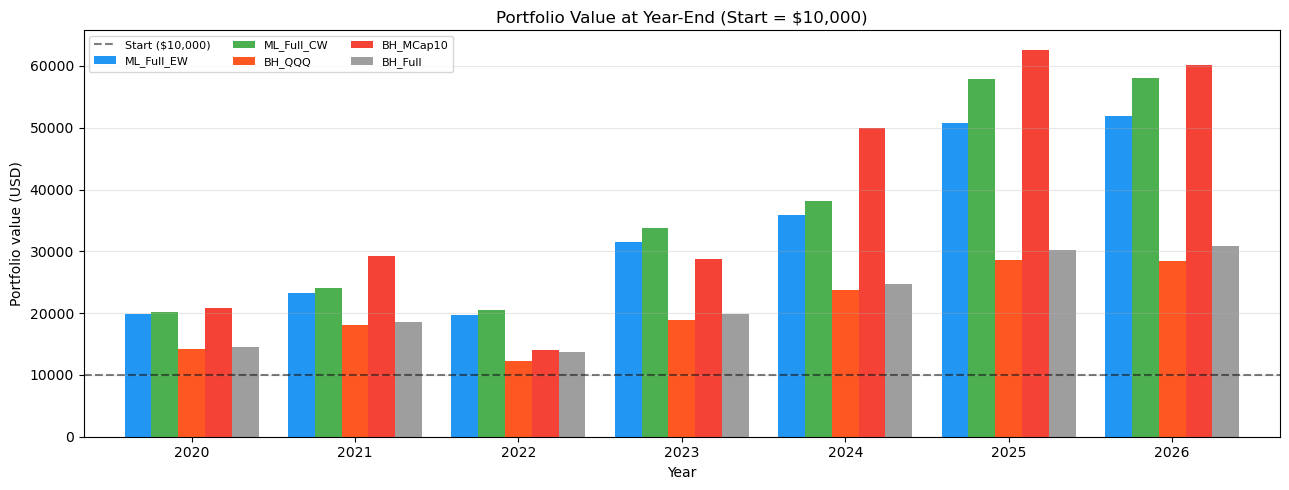

In [6]:
initial_capital = float(cfg.backtest.initial_capital)

def _yearend(eq):
    eq = eq.copy()
    eq.index = pd.to_datetime(eq.index)
    return eq.groupby(eq.index.year)['equity'].last()

ye = pd.DataFrame({n: _yearend(eq) for n, eq in equities.items()})
start_row = pd.DataFrame({n: initial_capital for n in equities}, index=['Start'])
ye = pd.concat([start_row, ye])

print(f'Portfolio value by year-end (start ${initial_capital:,.0f}):\n')
print(ye.map(lambda v: f'${v:>11,.0f}').to_string())

final = ye.iloc[-1]
mult = final / initial_capital
total_ret = (mult - 1) * 100
print('\n--- Final summary ---')
days = (pd.to_datetime(equities['ML_Full_EW'].index).max() - pd.to_datetime(equities['ML_Full_EW'].index).min()).days
print(f'Period: {days/365.25:.2f} years\n')
for n in equities:
    print(f'  {n:14s} final=${final[n]:>11,.0f}  ({mult[n]:.2f}x)  total={total_ret[n]:+7.1f}%')

fig, ax = plt.subplots(figsize=(13, 5))
plot_df = ye.drop('Start')
plot_df.index = plot_df.index.astype(str)
plot_df.plot(kind='bar', ax=ax, width=0.82, color=[colors.get(c, 'gray') for c in plot_df.columns])
ax.axhline(initial_capital, ls='--', color='black', alpha=0.5, label=f'Start (${initial_capital:,.0f})')
ax.set_title(f'Portfolio Value at Year-End (Start = ${initial_capital:,.0f})')
ax.set_ylabel('Portfolio value (USD)')
ax.set_xlabel('Year')
ax.legend(fontsize=8, ncol=3)
ax.grid(alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 4. Sensitivity Analysis Validation

Top-K:
 CAGR  Sharpe  top_k
0.198   0.552      3
0.270   0.725      5
0.214   0.618      8
0.193   0.576     10
0.151   0.477     15
0.154   0.494     20

Cost:
 CAGR  Sharpe  cost_bps
0.213   0.626         0
0.203   0.601         5
0.193   0.576        10
0.183   0.550        15
0.173   0.525        20
0.153   0.475        30

Rebalance:
 CAGR  Sharpe  rebalance_days
0.115   0.378               5
0.193   0.576              10
0.153   0.473              15
0.199   0.586              21



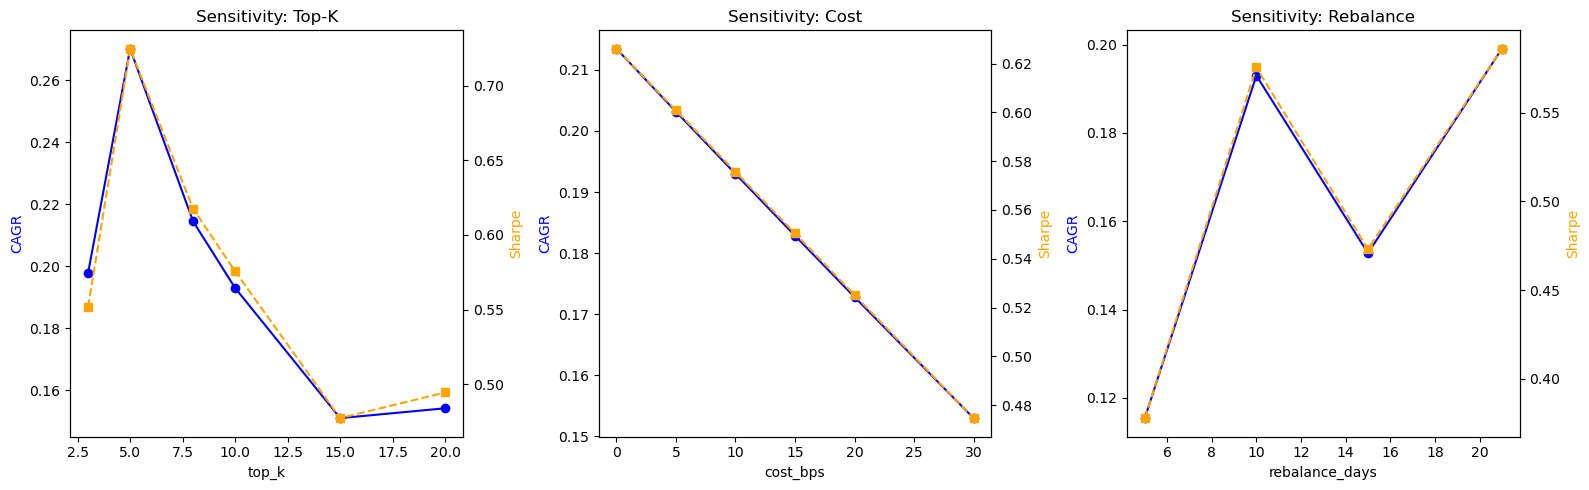

In [7]:
met_dir = cfg.dir_outputs / 'metrics'
sens_files = {
    'Top-K': 'sensitivity_topk.csv',
    'Cost': 'sensitivity_cost.csv',
    'Rebalance': 'sensitivity_rebalance.csv',
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (title, fname) in zip(axes, sens_files.items()):
    path = met_dir / fname
    if path.exists():
        s = pd.read_csv(path)
        x_col = s.columns[-1]
        ax.plot(s[x_col], s['CAGR'], 'o-', label='CAGR', color='blue')
        ax2 = ax.twinx()
        ax2.plot(s[x_col], s['Sharpe'], 's--', label='Sharpe', color='orange')
        ax.set_title(f'Sensitivity: {title}')
        ax.set_xlabel(x_col); ax.set_ylabel('CAGR', color='blue')
        ax2.set_ylabel('Sharpe', color='orange')
        print(f"{title}:")
        print(s[['CAGR', 'Sharpe', x_col]].round(3).to_string(index=False))
        print()
    else:
        ax.set_title(f'{title}: NOT FOUND')
plt.tight_layout(); plt.show()

## 5. Alpha Testing Results

In [8]:
alpha_path = cfg.dir_outputs / 'metrics' / 'alpha_stats.csv'
if alpha_path.exists():
    alpha_df = pd.read_csv(alpha_path)
    print("Alpha Testing (vs QQQ benchmark):")
    for _, row in alpha_df.iterrows():
        sig = 'YES' if row.get('p_value_alpha', 1) < 0.05 else 'no'
        print(f"  {row['strategy']}: t={row.get('t_stat_alpha',0):.3f}, "
              f"p={row.get('p_value_alpha',1):.4f} [{sig}], "
              f"alpha={row.get('Avg_Annual_Alpha',0)*100:.2f}%/yr")
else:
    print("SKIP: alpha_stats.csv not found")

Alpha Testing (vs QQQ benchmark):
  ML_Full_EW: t=1.257, p=0.2088 [no], alpha=9.16%/yr
  ML_Full_CW: t=1.534, p=0.1250 [no], alpha=11.68%/yr


## 6. Walk-Forward AUC per Fold

AUC per Fold (Full features):
model       LGBM     LR     RF
test_year                     
2020       0.538  0.520  0.537
2021       0.490  0.530  0.512
2022       0.470  0.514  0.474
2023       0.517  0.550  0.510
2024       0.471  0.523  0.481
2025       0.575  0.477  0.544
2026       0.380  0.284  0.486


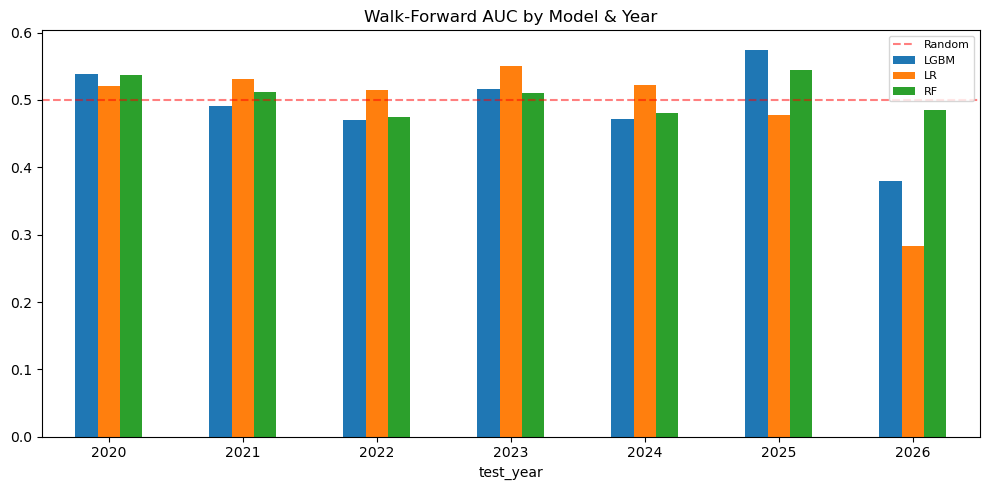


Fold-model cells > 0.5: 12/21


In [9]:
wf_path = cfg.dir_outputs / 'metrics' / 'walkforward_full.csv'
if wf_path.exists():
    wf = pd.read_csv(wf_path)
    pivot = wf.pivot_table(index='test_year', columns='model', values='daily_auc')
    print("AUC per Fold (Full features):")
    print(pivot.round(3).to_string())

    fig, ax = plt.subplots(figsize=(10, 5))
    pivot.plot(kind='bar', ax=ax, rot=0)
    ax.axhline(0.5, ls='--', color='red', alpha=0.5, label='Random')
    ax.set_title('Walk-Forward AUC by Model & Year'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    above_random = (pivot > 0.5).sum().sum()
    print(f"\nFold-model cells > 0.5: {above_random}/{pivot.size}")
else:
    print("SKIP: walkforward_full.csv not found")

## 7. Random Benchmark Distribution

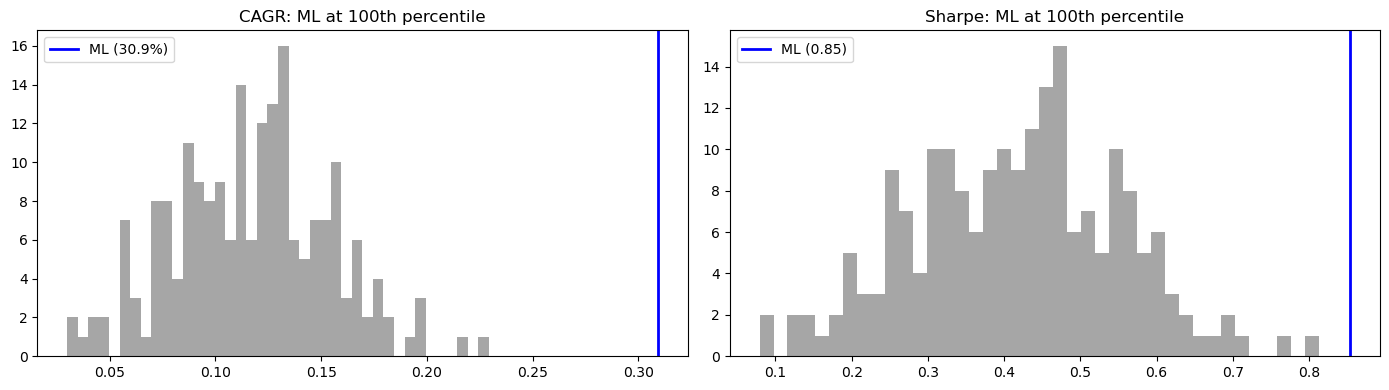

Random: 200 iters, CAGR=11.7%+/-3.7%
OK: ML outperforms random mean


In [10]:
rand_path = cfg.dir_outputs / 'metrics' / 'random_benchmark_stats.csv'
if rand_path.exists():
    rand = pd.read_csv(rand_path)
    ml_cagr = all_metrics.get('ML_Full_EW', {}).get('CAGR', 0)
    ml_sharpe = all_metrics.get('ML_Full_EW', {}).get('Sharpe', 0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(rand['CAGR'], bins=40, color='gray', edgecolor='none', alpha=0.7)
    axes[0].axvline(ml_cagr, color='blue', linewidth=2, label=f'ML ({ml_cagr:.1%})')
    pct_cagr = (rand['CAGR'] < ml_cagr).mean() * 100
    axes[0].set_title(f'CAGR: ML at {pct_cagr:.0f}th percentile'); axes[0].legend()

    axes[1].hist(rand['Sharpe'], bins=40, color='gray', edgecolor='none', alpha=0.7)
    axes[1].axvline(ml_sharpe, color='blue', linewidth=2, label=f'ML ({ml_sharpe:.2f})')
    pct_sharpe = (rand['Sharpe'] < ml_sharpe).mean() * 100
    axes[1].set_title(f'Sharpe: ML at {pct_sharpe:.0f}th percentile'); axes[1].legend()
    plt.tight_layout(); plt.show()

    print(f"Random: {len(rand)} iters, CAGR={rand['CAGR'].mean():.1%}+/-{rand['CAGR'].std():.1%}")
    assert ml_cagr > rand['CAGR'].mean(), "ML CAGR below random mean!"
    print("OK: ML outperforms random mean")
else:
    print("SKIP: random_benchmark_stats.csv not found")

## 8. Sector Constraint Check

In [11]:
print(f"Sector map: {len(SECTOR_MAP)} tickers mapped")
print(f"Sector max weight: {cfg.backtest.sector_max_weight}")
print(f"\nSector distribution:")
sector_counts = pd.Series(SECTOR_MAP).value_counts()
print(sector_counts.to_string())

df = load(cfg.dir_processed / 'dataset.parquet')
tickers = set(df.index.get_level_values('ticker').unique())
unmapped = tickers - set(SECTOR_MAP.keys())
if unmapped:
    print(f"\nWARNING: {len(unmapped)} tickers not in SECTOR_MAP: {unmapped}")
else:
    print(f"\nOK: All {len(tickers)} tickers have sector mapping")

Sector map: 72 tickers mapped
Sector max weight: 0.4

Sector distribution:
Technology                24
Consumer Discretionary    11
Health Care               11
Industrials                9
Communication Services     8
Consumer Staples           7
Financials                 1
Utilities                  1

OK: All 68 tickers have sector mapping


## 9. Trade Log Analysis

Trade log: 148 rebalances
  Avg holdings: 10.0
  Avg turnover: 0.664
  Avg cost: 0.0008


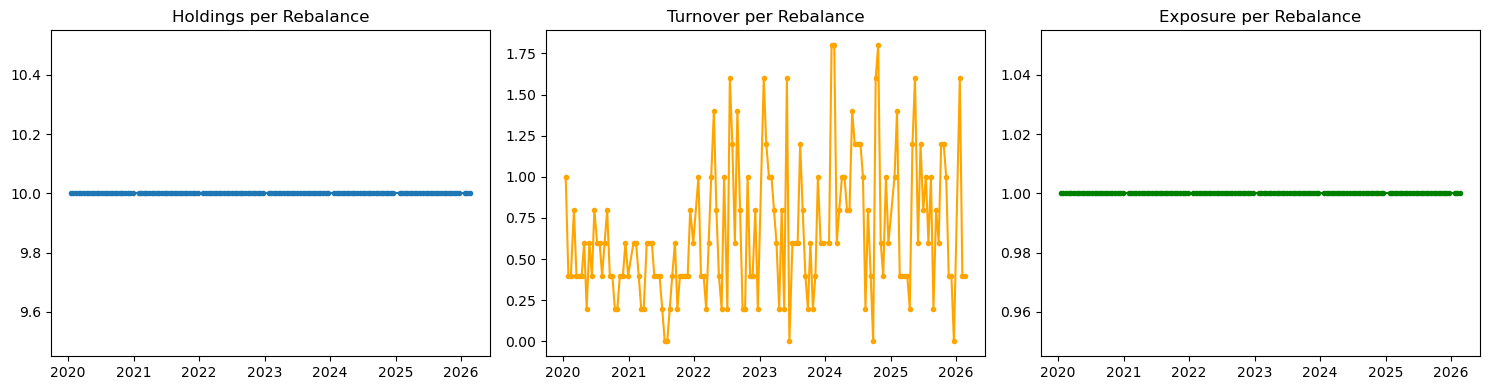

In [12]:
trade_path = cfg.dir_outputs / 'metrics' / 'trade_log_full.csv'
if trade_path.exists():
    trades = pd.read_csv(trade_path)
    print(f"Trade log: {len(trades)} rebalances")
    print(f"  Avg holdings: {trades['n_holdings'].mean():.1f}")
    print(f"  Avg turnover: {trades['turnover_est'].mean():.3f}")
    print(f"  Avg cost: {trades['cost'].mean():.4f}")

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(pd.to_datetime(trades['rebalance_date']), trades['n_holdings'], 'o-', markersize=3)
    axes[0].set_title('Holdings per Rebalance')
    axes[1].plot(pd.to_datetime(trades['rebalance_date']), trades['turnover_est'], 'o-', markersize=3, color='orange')
    axes[1].set_title('Turnover per Rebalance')
    axes[2].plot(pd.to_datetime(trades['rebalance_date']), trades['exposure'], 'o-', markersize=3, color='green')
    axes[2].set_title('Exposure per Rebalance')
    plt.tight_layout(); plt.show()
else:
    print("SKIP: trade_log_full.csv not found")

## 10. Full Pipeline Summary

In [13]:
print("=" * 60)
print("06_analysis: ALL CHECKS PASSED")
print("=" * 60)
print(f"\nStrategies: {list(equities.keys())}")
print(f"\nKey Results:")
for name in ['ML_Full_EW', 'ML_Full_CW', 'BH_QQQ']:
    if name in all_metrics:
        m = all_metrics[name]
        print(f"  {name}: CAGR={m['CAGR']:.1%}, Sharpe={m['Sharpe']:.2f}, MDD={m['Max_Drawdown']:.1%}")

print(f"\nOutput files verified:")
met_dir = cfg.dir_outputs / 'metrics'
for name in ['backtest_metrics.csv', 'alpha_stats.csv', 'walkforward_full.csv',
             'random_benchmark_stats.csv', 'sensitivity_topk.csv',
             'trade_log_full.csv', 'trade_summary.csv']:
    status = 'OK' if (met_dir / name).exists() else 'MISSING'
    print(f"  [{status}] {name}")
print("=" * 60)

06_analysis: ALL CHECKS PASSED

Strategies: ['ML_Full_EW', 'ML_Full_CW', 'BH_QQQ', 'BH_MCap10', 'BH_Full']

Key Results:
  ML_Full_EW: CAGR=30.9%, Sharpe=0.85, MDD=-37.2%
  ML_Full_CW: CAGR=33.3%, Sharpe=0.89, MDD=-37.6%
  BH_QQQ: CAGR=18.6%, Sharpe=0.67, MDD=-35.1%

Output files verified:
  [OK] backtest_metrics.csv
  [OK] alpha_stats.csv
  [OK] walkforward_full.csv
  [OK] random_benchmark_stats.csv
  [OK] sensitivity_topk.csv
  [OK] trade_log_full.csv
  [OK] trade_summary.csv
